## CZESC PIERWSZA

### Instalacja pakietow

Zdecydowalismy sie na pobranie takich o to pakietow:  
- `tidyverse` - do wizualizacji
- `janitor`- pomocne przy porzadkowaniu nazw kolumn
- `skimr`- podsumowanie odnosnie statystyk

In [2]:
install.packages(c("tidyverse", "janitor", "skimr"))

library(tidyverse)
library(janitor) 
library(skimr) 

install.packages("here")
library(here)

install.packages("patchwork")
library(patchwork)



Pobrane pakiety binarne sa w
	/var/folders/yt/7ptvhg8x3pj99thz7twr6d340000gn/T//RtmpkITVBc/downloaded_packages


-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.1.4     v readr     2.1.5
v forcats   1.0.0     v stringr   1.5.1
v ggplot2   3.5.1     v tibble    3.2.1
v lubridate 1.9.4     v tidyr     1.3.1
v purrr     1.0.4     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Dolaczanie pakietu: 'janitor'


Nastepujace obiekty zostaly zakryte z 'package:stats':

    chisq.test, fisher.test





Pobrane pakiety binarne sa w
	/var/folders/yt/7ptvhg8x3pj99thz7twr6d340000gn/T//RtmpkITVBc/downloaded_packages


here() starts at /Users/michaelbak/Desktop




Pobrane pakiety binarne sa w
	/var/folders/yt/7ptvhg8x3pj99thz7twr6d340000gn/T//RtmpkITVBc/downloaded_packages


### Wczytanie danych

`clean_names()` sprzata nazwy kolumn, czyli spacje zamienia na podkreslenia, wielkie litery na male ***(Central AAir --> central_air)***.  
  
`glimpse()` sluzy do poweidzmy kolokwialnie *'rzucenia okiem'* na dane.

In [6]:
ames_raw <-read_csv(here("UNIVERSITY", "AmesHousing.csv")) |> clean_names()
glimpse(ames_raw)

Rows: 2930 Columns: 82
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (45): PID, MS SubClass, MS Zoning, Street, Alley, Lot Shape, Land Contou...
dbl (37): Order, Lot Frontage, Lot Area, Overall Qual, Overall Cond, Year Bu...

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00C4>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00D6>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00DC>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00E4>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00F6>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00FC>' to native encoding"
Warning message in FUN(X[[i]], .

Rows: 2,930
Columns: 82
$ order           <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,~
$ pid             <chr> "0526301100", "0526350040", "0526351010", "0526353030"~
$ ms_sub_class    <chr> "020", "020", "020", "020", "060", "060", "120", "120"~
$ ms_zoning       <chr> "RL", "RH", "RL", "RL", "RL", "RL", "RL", "RL", "RL", ~
$ lot_frontage    <dbl> 141, 80, 81, 93, 74, 78, 41, 43, 39, 60, 75, NA, 63, 8~
$ lot_area        <dbl> 31770, 11622, 14267, 11160, 13830, 9978, 4920, 5005, 5~
$ street          <chr> "Pave", "Pave", "Pave", "Pave", "Pave", "Pave", "Pave"~
$ alley           <chr> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA~
$ lot_shape       <chr> "IR1", "Reg", "IR1", "Reg", "IR1", "IR1", "Reg", "IR1"~
$ land_contour    <chr> "Lvl", "Lvl", "Lvl", "Lvl", "Lvl", "Lvl", "Lvl", "HLS"~
$ utilities       <chr> "AllPub", "AllPub", "AllPub", "AllPub", "AllPub", "All~
$ lot_config      <chr> "Corner", "Inside", "Corner", "Corner", "Inside", "Ins~
$ land_slope    

Jak widac dane zostaly wczytane.  
Widzimy tutaj podsumwoanie danych..  
- 2930 obserwacji
- 82 kolumny
- 45 zmienncyh znakowcyh
- 37 zmiennych liczbowych
- nazwy kolumn zostaly zmienione na snake case

### Opis zbioru danych

Zdecydowaliśmy sie na **Ames Housing Dataset** jako nasz unikalny zbiór danych.  
Zbiór danych pochodzi z Kaggle [Ames Data Set](https://www.kaggle.com/datasets/shashanknecrothapa/ames-housing-dataset).  

- **Liczba obserwacji:** 2 930  
- **Liczba cech:** 79  
- **Cechy:** różnorodne atrybuty opisujące domy  
- **Zmienna docelowa:** `SalePrice` (cena sprzedaży domu w USD)  

Opis zbioru danych na Kaggle:
> _“The Ames Housing Dataset is widely used in the machine learning community for tasks such as regression modeling, feature engineering, and predictive analytics related to housing prices. It serves as a valuable resource for developing and testing machine learning algorithms and techniques in the real estate domain.”_    

Podsumowujac, z tychze 79 cech wybralismy:
- ogolne 14 cech
    - 7 cech dyskretnych  
    - 7 cech ciągłych


Dzięki wybraniu 7 zmiennych dyskretnych i 7 zmiennych ciągłych, uzyskujemy zrównoważony zestaw danych idealny do dalszej analizy statystycznej.


### Podzbior danych & opis

Nastepnie budujemy podzbior z naszych 14 wybranych cech.  

In [7]:
sel_vars <- c("central_air", "paved_drive", "bsmt_full_bath", "kitchen_abv_gr", "fireplaces", "bsmt_half_bath","garage_cars", "lot_area", "gr_liv_area", "total_bsmt_sf", "x1st_flr_sf","x2nd_flr_sf", "garage_area", "sale_price")
ames <- ames_raw |> select(all_of(sel_vars))

1. **`Central Air`**  
   - **Opis:** Czy budynek posiada klimatyzację (`Y`/`N`).  
   - **Typ:** Zmienna binarna (2 wartości).  
   - **Zakres wartości:** `Y` (tak), `N` (nie).  

2. **`Paved Drive`**  
   - **Opis:** Rodzaj utwardzenia podjazdu.  
   - **Typ:** Zmienna nominalna.  
   - **Zakres wartości:** `N` (brak utwardzenia), `P` (częściowe), `Y` (tak).  

3. **`Bsmt Full Bath`**  
   - **Opis:** Liczba pełnych łazienek w piwnicy.  
   - **Typ:** Zmienna licznikowa.  
   - **Zakres wartości:** 0–3.  

4. **`Kitchen AbvGr`**  
   - **Opis:** Liczba kuchni nad poziomem gruntu.  
   - **Typ:** Zmienna licznikowa.  
   - **Zakres wartości:** zwykle 1–2.  

5. **`Fireplaces`**  
   - **Opis:** Liczba kominków w domu.  
   - **Typ:** Zmienna licznikowa.  
   - **Zakres wartości:** 0–4.  

6. **`Bsmt Half Bath`**  
   - **Opis:** Liczba „połówkowych” łazienek w piwnicy.  
   - **Typ:** Zmienna licznikowa.  
   - **Zakres wartości:** 0–2.  

7. **`Garage Cars`**  
   - **Opis:** Liczba miejsc parkingowych w garażu.  
   - **Typ:** Zmienna licznikowa.  
   - **Zakres wartości:** 0–4.  

---

*Zdecydowalismy sie na wybor takich cech, poniewaz kazda z nich ma liczbe unikatowych wartosci (<10), dobrze bedzie sie je wizualizowac, uwazamy ze dobrze oddadza wplyw na atrakcyjnosc mieszkania*

1. **`Lot Area`**  
   - **Opis:** Powierzchnia działki w stopach kwadratowych.  
   - **Typ:** Zmienna ciągła.  
   - **Zakres wartości:** od kilku tysięcy do ponad 200 000 ft².

2. **`Gr Liv Area`**  
   - **Opis:** Powierzchnia użytkowa mieszkalna powyżej poziomu gruntu w stopach kwadratowych. 
   - **Typ:** Zmienna ciągła.  
   - **Zakres wartości:** od kilkuset do ponad 4500 ft².

3. **`Total Bsmt SF`**  
   - **Opis:** Całkowita powierzchnia piwnicy w stopach kwadratowych.  
   - **Typ:** Zmienna ciągła.  
   - **Zakres wartości:** od 0 (brak piwnicy) do około 6000 w stopach kwadratowych.

4. **`1st Flr SF`**  
   - **Opis:** Powierzchnia parteru w stopach kwadratowych.  
   - **Typ:** Zmienna ciągła.  
   - **Zakres wartości:** od kilkuset do ponad 4000 ft².

5. **`2nd Flr SF`**  
   - **Opis:** Powierzchnia piętra w stopach kwadratowych. 
   - **Typ:** Zmienna ciągła.  
   - **Zakres wartości:** od 0 (domy parterowe) do około 2000 ft².

6. **`Garage Area`**  
   - **Opis:** Powierzchnia garażu w stopach kwadratowych. 
   - **Typ:** Zmienna ciągła.  
   - **Zakres wartości:** od 0 (brak garażu) do ponad 1400 ft².

7. **`SalePrice`**  
   - **Opis:** Cena sprzedaży domu w dolarach amerykańskich.  
   - **Typ:** Zmienna ciągła.  
   - **Zakres wartości:** od kilkudziesięciu tysięcy do ponad miliona dolarów.


In [8]:
ames

central_air,paved_drive,bsmt_full_bath,kitchen_abv_gr,fireplaces,bsmt_half_bath,garage_cars,lot_area,gr_liv_area,total_bsmt_sf,x1st_flr_sf,x2nd_flr_sf,garage_area,sale_price
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Y,P,1,1,2,0,2,31770,1656,1080,1656,0,528,215000
Y,Y,0,1,0,0,1,11622,896,882,896,0,730,105000
Y,Y,0,1,0,0,1,14267,1329,1329,1329,0,312,172000
Y,Y,1,1,2,0,2,11160,2110,2110,2110,0,522,244000
Y,Y,0,1,1,0,2,13830,1629,928,928,701,482,189900
Y,Y,0,1,1,0,2,9978,1604,926,926,678,470,195500
Y,Y,1,1,0,0,2,4920,1338,1338,1338,0,582,213500
Y,Y,0,1,0,0,2,5005,1280,1280,1280,0,506,191500
Y,Y,1,1,1,0,2,5389,1616,1595,1616,0,608,236500


Nasz nowy zbiór, na którym będziemy pracować, składa się z:
- **14 cech**:  
  - 7 cech dyskretnych  
  - 7 cech ciągłych  
- **2930 obserwacji**  

Ograniczylismy sie do tych 14 cech, zatem duzo latwiejsze staje sie przeprowadzenie analizy dancyh jak i sama wizualizacja danych.  
Dodatkwo zachowujemy balans miedzy zmiennyli liczbowymi a kategorycznymi.


### Ustawianie wlaciwych typow danych

Ten krok zdecydowalismy sie podjac z powodu tego, iz w `ggplot2` latwiej sie tworzy wizualizacje.  
Dodatkowo `factor` zapobiega przypadkowemu potraktowaniu liczby (np. liczby kominków) jako zmiennej ciągłej.

In [9]:
discrete_cols <- c("central_air", "paved_drive", "bsmt_full_bath","kitchen_abv_gr", "fireplaces", "bsmt_half_bath","garage_cars")

ames <- ames |>
  mutate(across(all_of(discrete_cols), as.factor))


a wiec, 
- `mutate`() nadpisuje oryginalne kolumny nową
- `across()` iteruje po wskazanych kolumnach
- `as.factor()` pobiera każdą kolumnę, zamienia na **factor**

Przykad:
`centra_air`:`Y`/`N` ***jako tekst*** vs `Y`/`N` ***jako dwie kategorie***

### Braki w dany

W tym punkcie sprawdzamy braki, gdzie w obserwacjach wystaepuja braki i w ktorym miejscu.  
Jesli kolumna `value > 0` to kolumna ma braki *(cecha)*.  

In [10]:
ames |> summarise(across(everything(), ~ sum(is.na(.)))) |> pivot_longer(everything()) 


name,value
<chr>,<int>
central_air,0
paved_drive,0
bsmt_full_bath,2
kitchen_abv_gr,0
fireplaces,0
bsmt_half_bath,2
garage_cars,1
lot_area,0
gr_liv_area,0


In [11]:
ames <- ames |> drop_na()

In [12]:
ames |> summarise(across(everything(), ~ sum(is.na(.)))) |> pivot_longer(everything()) 


name,value
<chr>,<int>
central_air,0
paved_drive,0
bsmt_full_bath,0
kitchen_abv_gr,0
fireplaces,0
bsmt_half_bath,0
garage_cars,0
lot_area,0
gr_liv_area,0


Skomentujmy, mamy ponad 2900 obserwacji, brakow yszlo 5 w danych kolumnach, co stanowi ulamek wszystkich obserwacji. Dlatego zdecydowalismy sie na:  
- `drop_na()` usuwaniecie wierszy gdzie nie ma wartosci cechy.
    - banalnie proste
    - nie ma potrzeby imputacji danych  
  
Inna strategia byloby `imputacja dancyh` wtedy zachowujemy wszystkie obserwacje, takie podejscie rozwazylibysmy gdyby brakuajcych danych bylo znacznie wiecej.

In [13]:
skim(ames)

-- Data Summary ------------------------
                           Values
Name                       ames  
Number of rows             2927  
Number of columns          14    
_______________________          
Column type frequency:           
  factor                   7     
  numeric                  7     
________________________         
Group variables            None  

-- Variable type: factor -------------------------------------------------------
  skim_variable  n_missing complete_rate ordered n_unique
1 central_air            0             1 FALSE          2
2 paved_drive            0             1 FALSE          3
3 bsmt_full_bath         0             1 FALSE          4
4 kitchen_abv_gr         0             1 FALSE          4
5 fireplaces             0             1 FALSE          5
6 bsmt_half_bath         0             1 FALSE          3
7 garage_cars            0             1 FALSE          6
  top_counts                     
1 Y: 2731, N: 196                
2 Y: 

ERROR: Error in is.null(text_repr) || nchar(text_repr) == 0L: 'length = 15' in coercion to 'logical(1)'


### Wizualizacja

In [14]:
disc_vars <- c("central_air", "paved_drive", "bsmt_full_bath",
               "kitchen_abv_gr", "fireplaces", "bsmt_half_bath",
               "garage_cars")

cont_vars <- c("lot_area", "gr_liv_area", "total_bsmt_sf",
               "x1st_flr_sf", "x2nd_flr_sf", "garage_area",
               "sale_price")

Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
i Please use tidy evaluation idioms with `aes()`.
i See also `vignette("ggplot2-in-packages")` for more information."


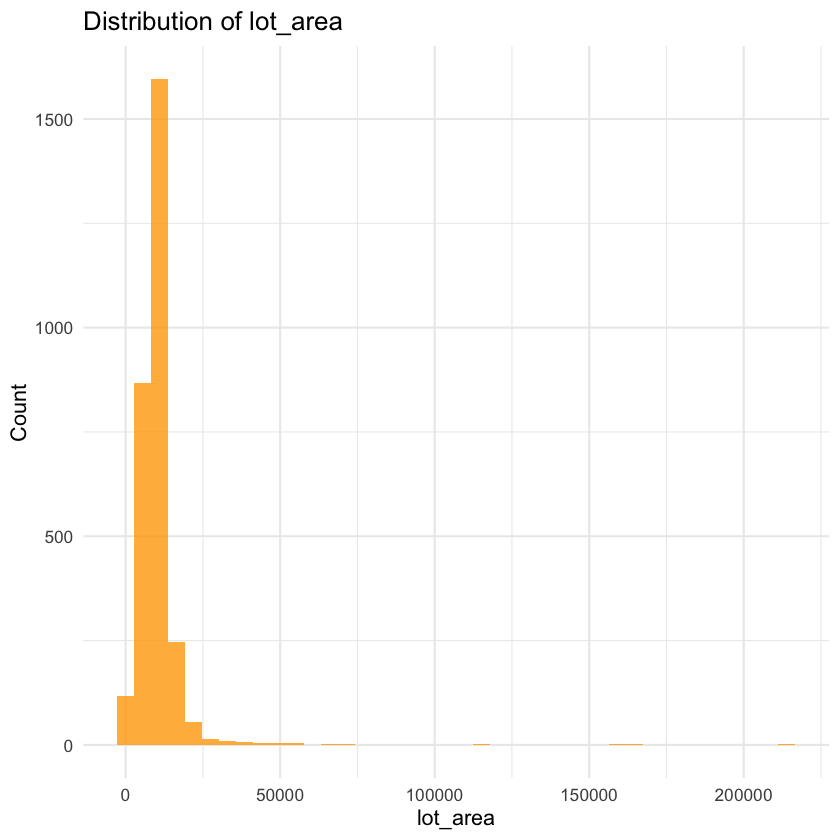

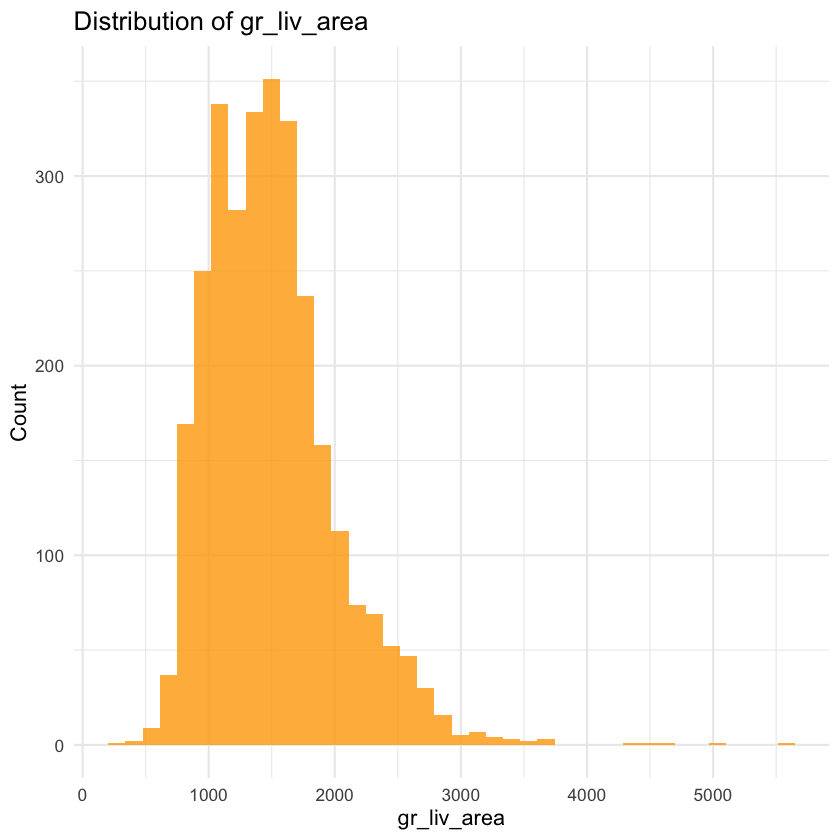

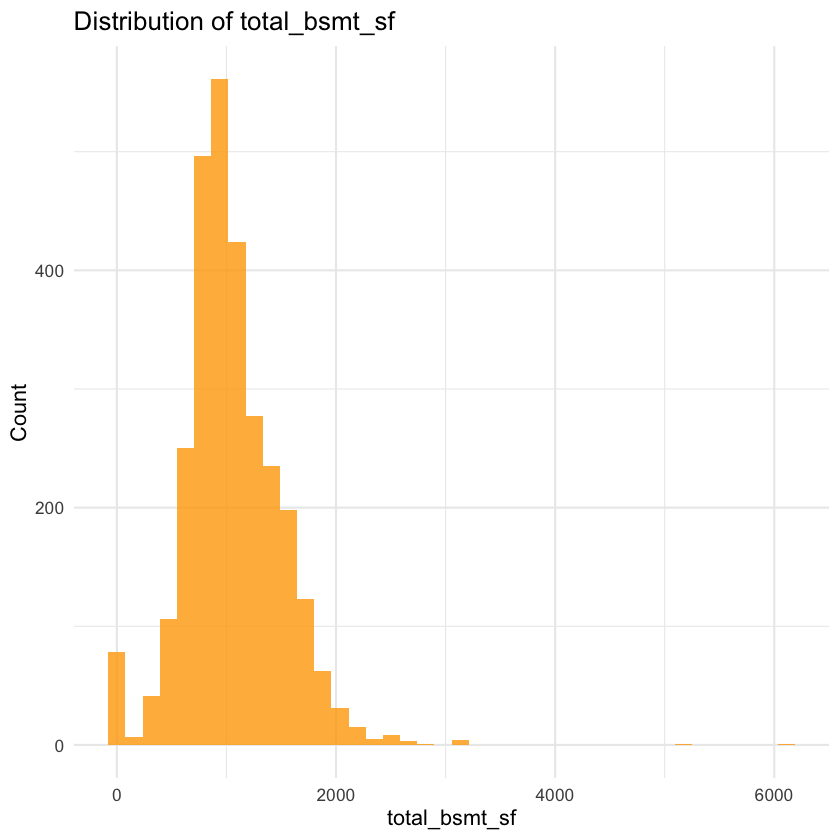

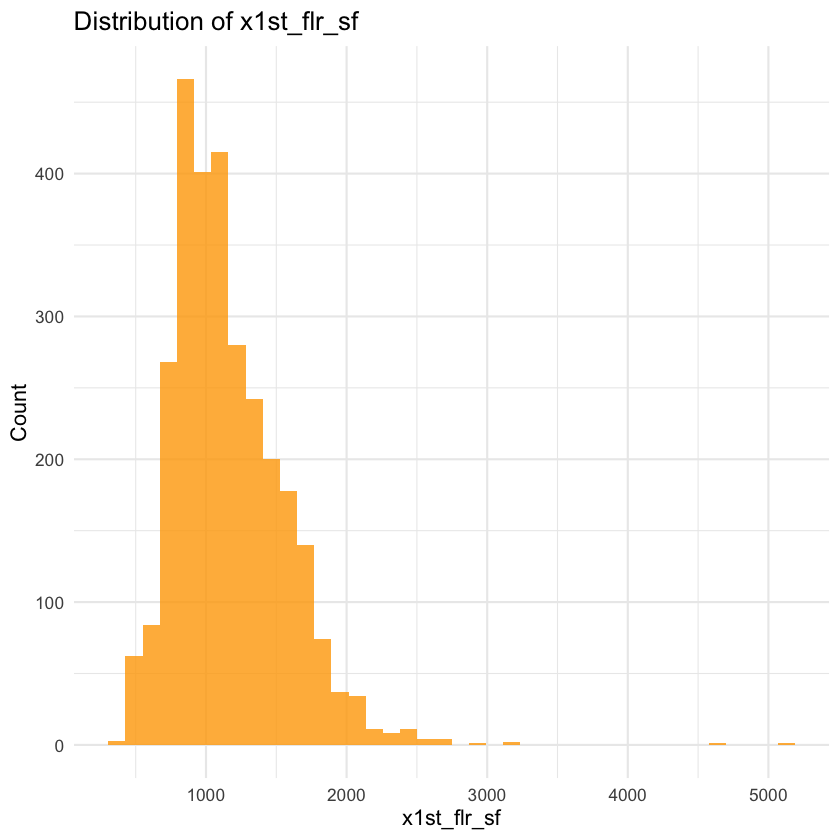

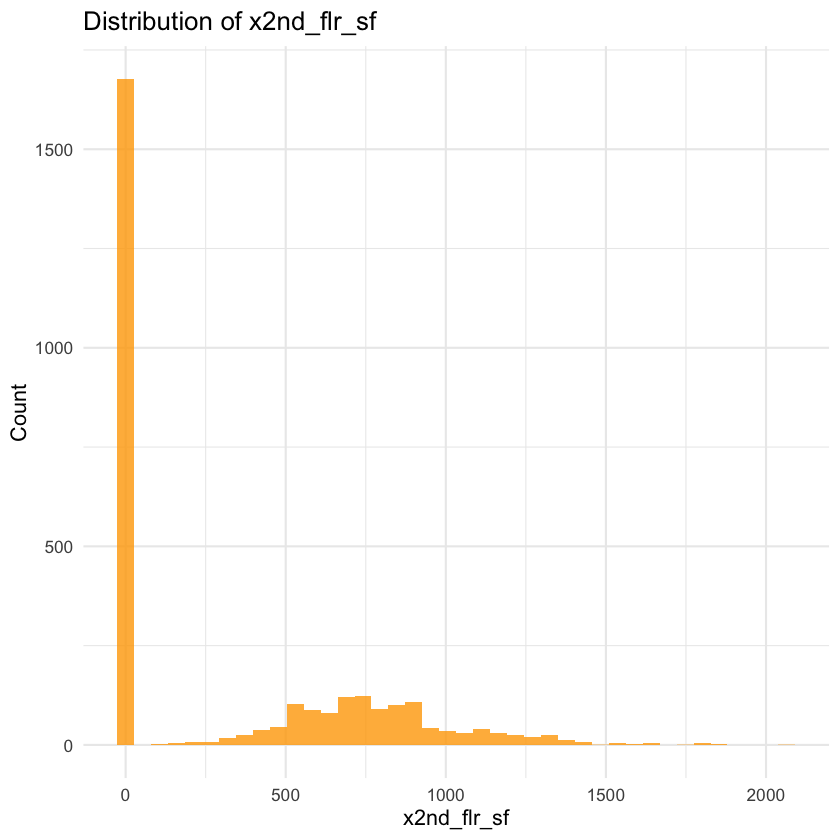

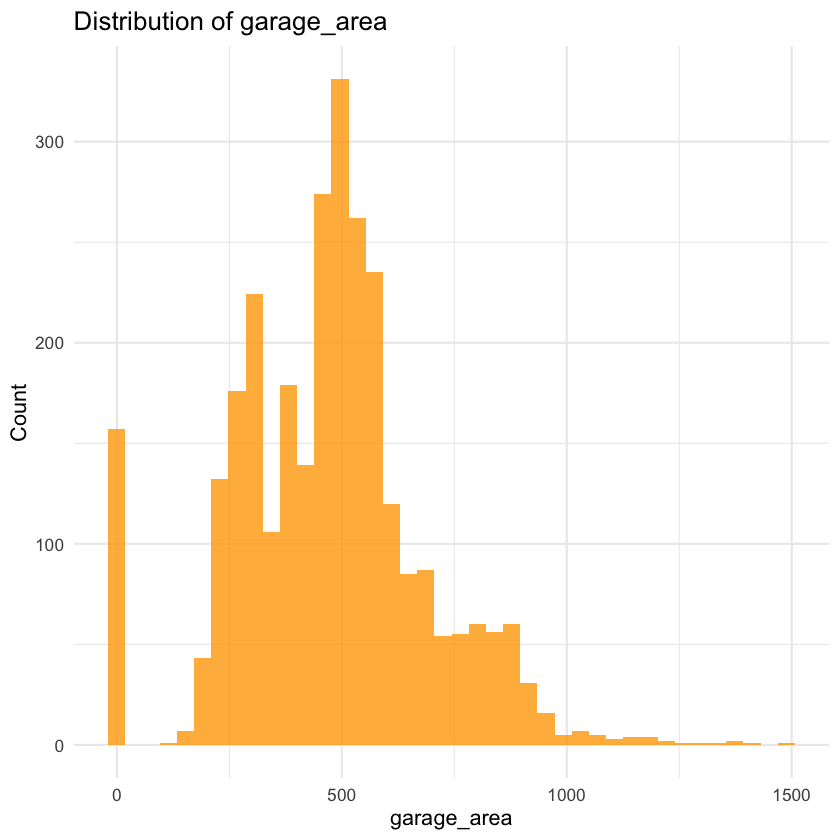

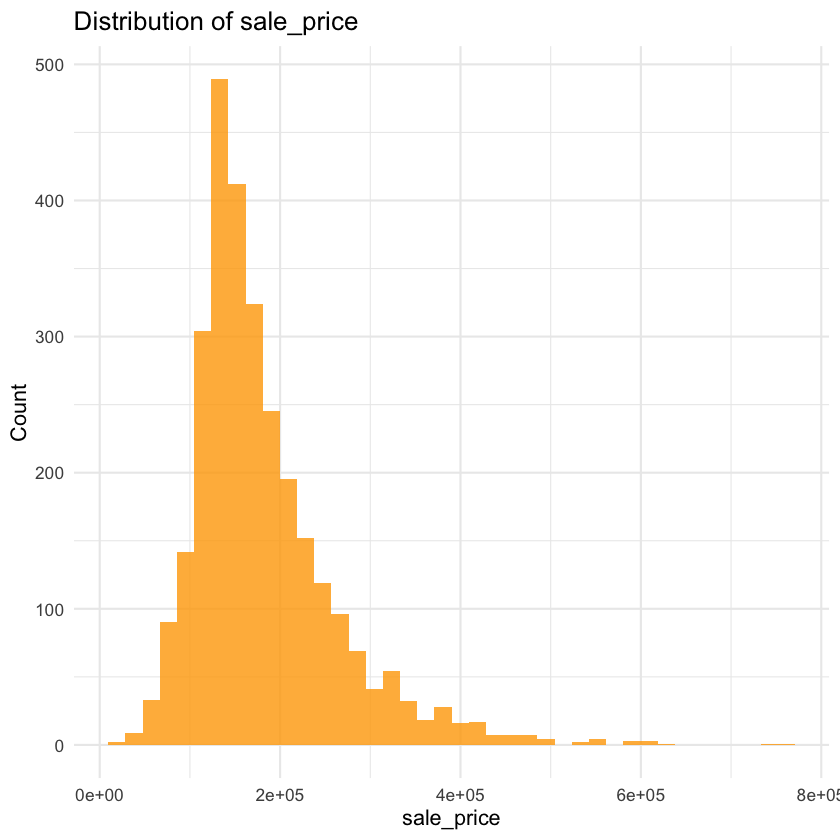

In [15]:
for (v in cont_vars) {
  ggplot(ames, aes_string(x = v)) +
    geom_histogram(bins = 40, fill = "#FFA600", alpha = 0.8) +
    labs(title = paste("Distribution of", v),
         x = v,
         y = "Count") +
    theme_minimal(base_size = 13) -> p
  print(p)
}


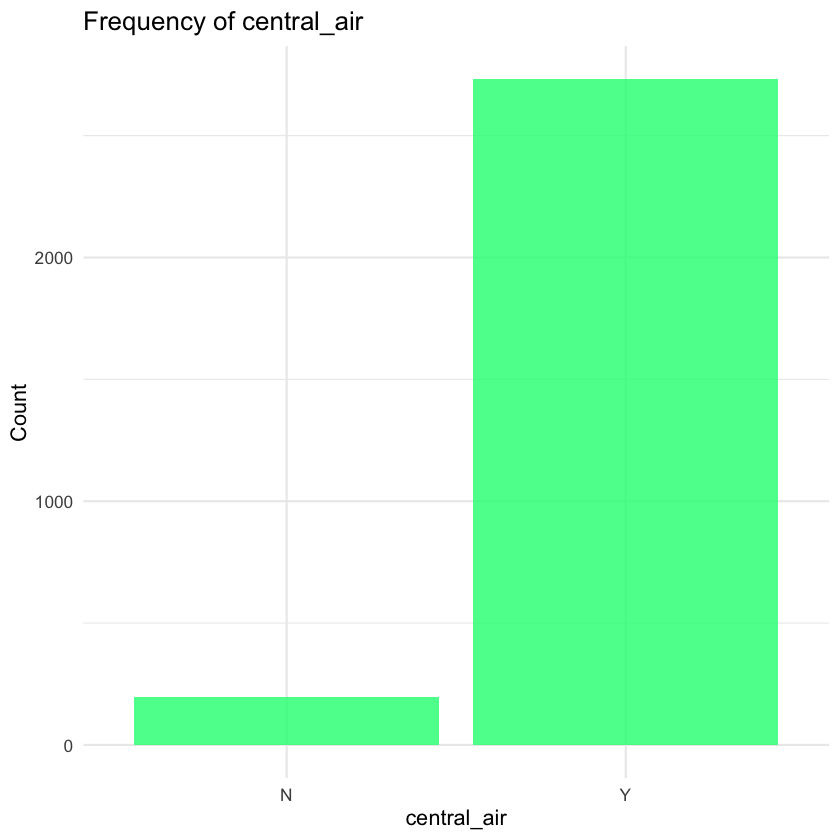

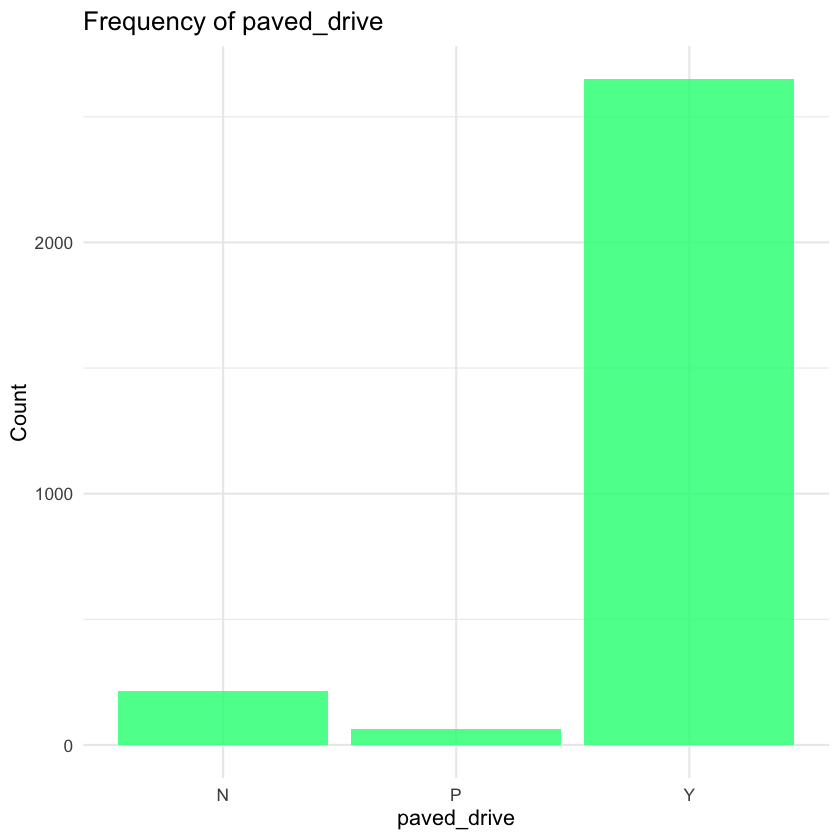

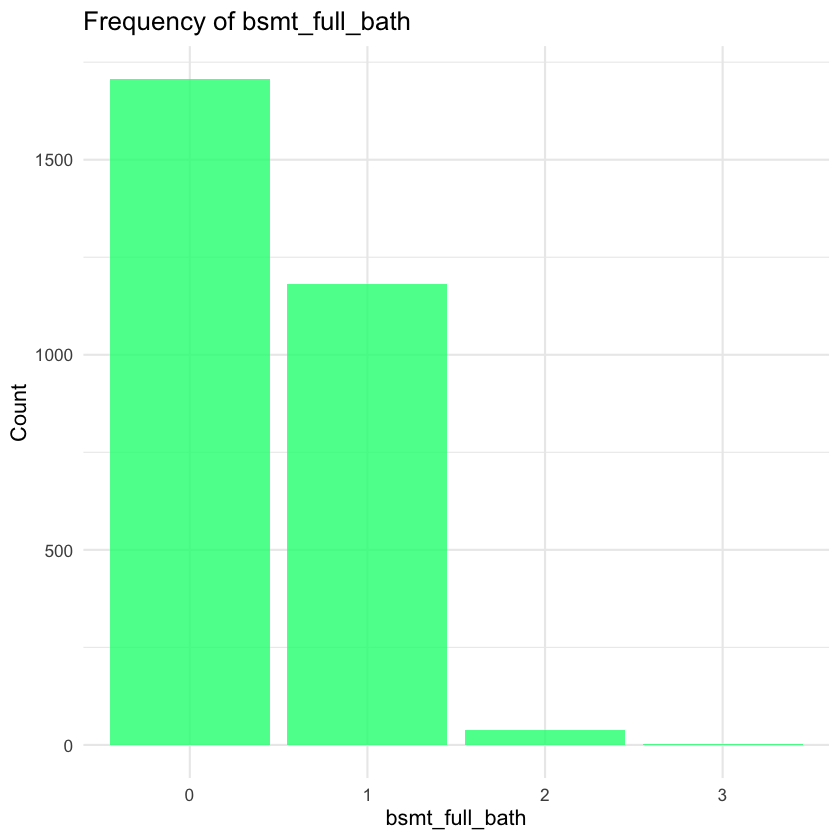

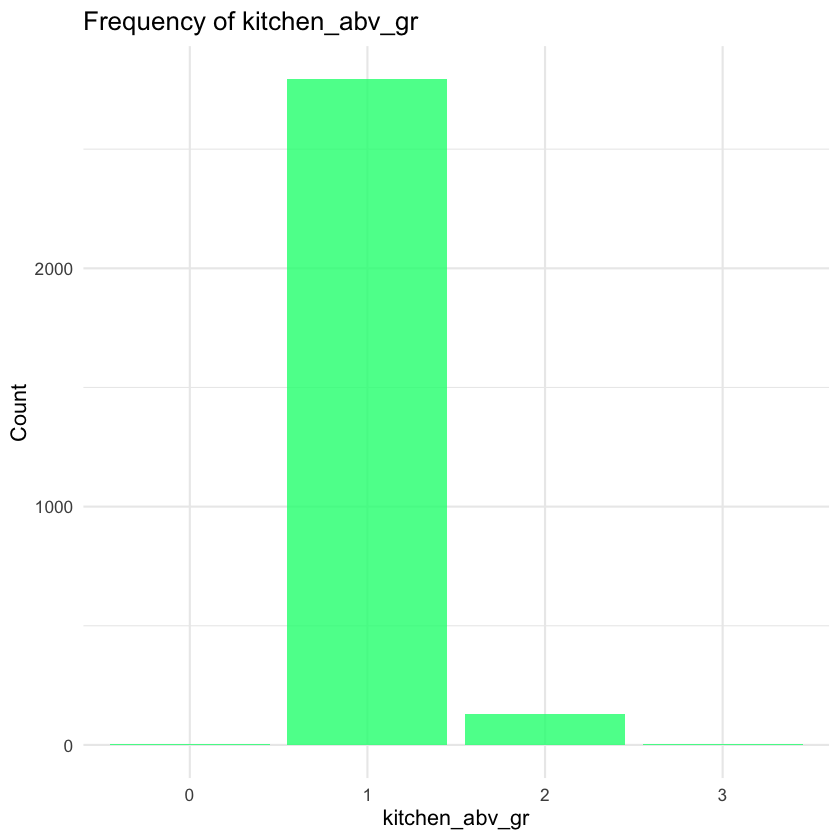

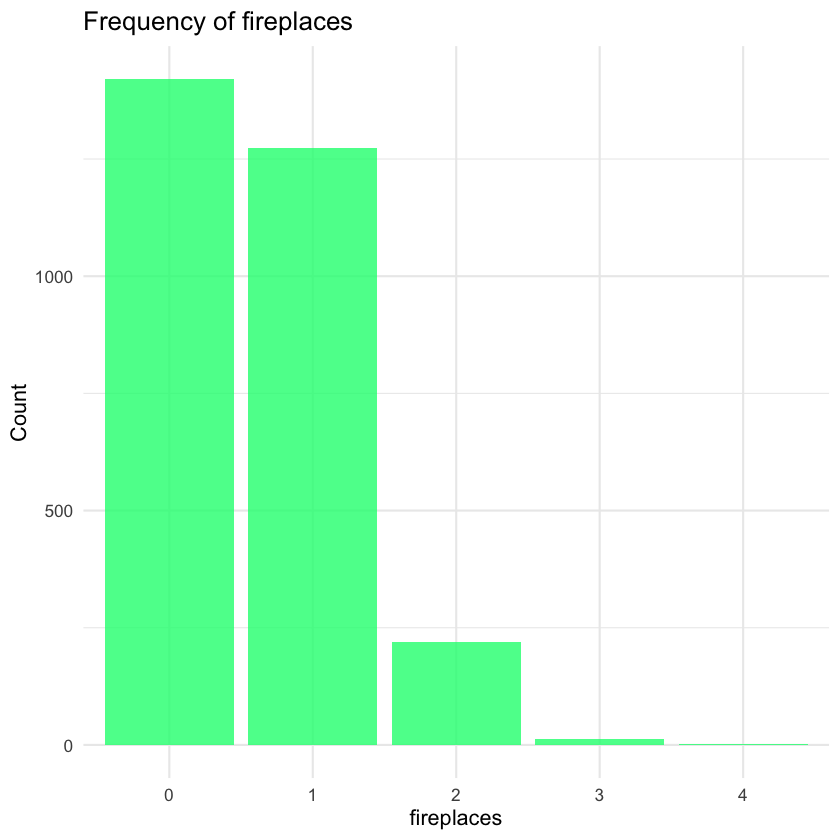

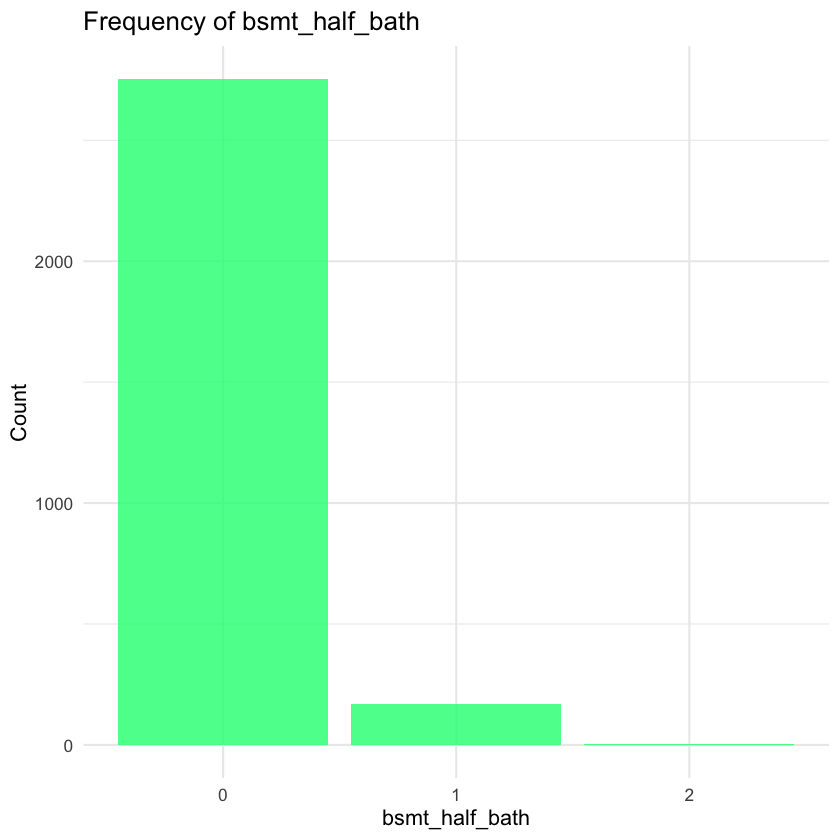

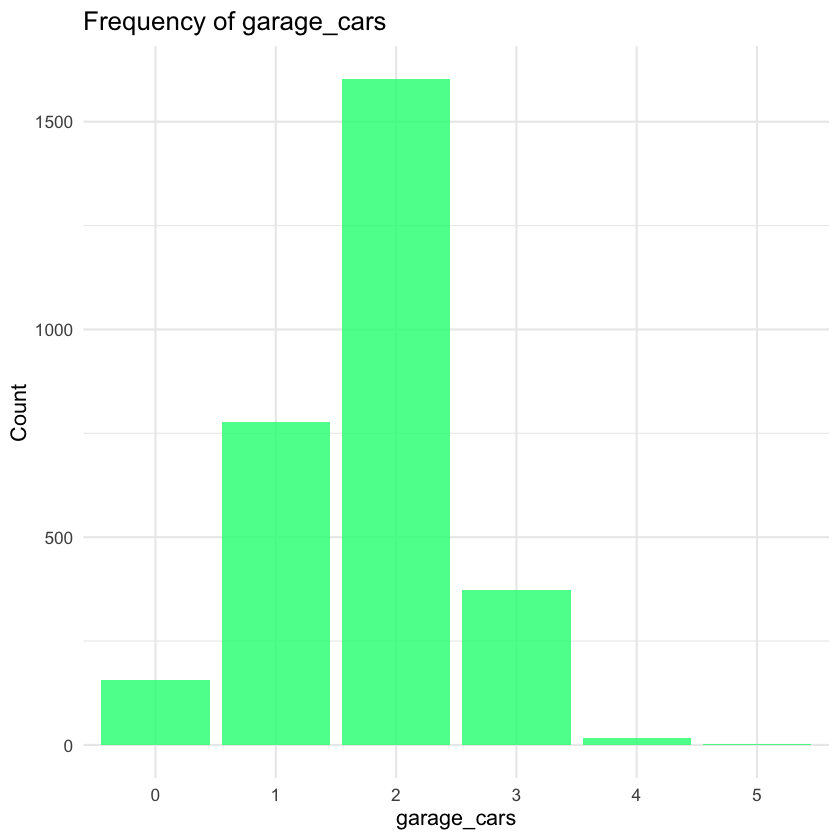

In [16]:
for (v in disc_vars) {
  ggplot(ames, aes_string(x = v)) +
    geom_bar(fill = "#00ff7f", alpha = 0.8) +
    labs(title = paste("Frequency of", v),
         x = v,
         y = "Count") +
    theme_minimal(base_size = 13) -> p
  print(p)
}


Podzielilimsy dane na dwie grupy tj:
- `disc_vars` cechy dyskretne
- `cont_vars` cechy ciagle

Nastpenie przy uzyciu petli `for` idziemy przez kazda ceche i wyswietlamy dla niej wykres, taki rozklad zmiennej.  
  
Tytuly sa w jezyku angielskim by uniknac problemow z wyswietlaniem nazwy wykresu.  
  


### Podsumowanie

Podsumujmy sobei co zrobilismy do tej pory,
- zaimportwoalismy najwazneisjze biblioteki ualtwaijace zycie i prace z danymi czy z wizualizacja danych,
- wczytalismy sb zbior, przejrzelismy go sobie
- wyrbalismye 14 cech tak jak w poprzednich projektach
- zmienilismy typ danych na `factor`
- sprawdzilismy braki i je usunelismy
- zwizualizowalismy kazde ceche z ktora bedziemy pracowac

## CZESC DRUGA

W tej czesci zajmiemy sie jzu wlasciwym budowaniem modelu regresji wielorakiej.

### Instalacja biliotek

Wykorzytsane bilbioteki:
- `e1071` do badania skosnosci

In [17]:
install.packages("e1071")
library(e1071)


Pobrane pakiety binarne sa w
	/var/folders/yt/7ptvhg8x3pj99thz7twr6d340000gn/T//RtmpkITVBc/downloaded_packages


### Log-Transformacja *SalePrice*

In [18]:
ames <- ames |> mutate(log_sale_price = log1p(sale_price))

Dodajemy zmienna `log_sale_price` w celu zbadania czy zachowa sie lepiej, czy nada sie lepiej do regresji wielorakiej niz `SalePice`.

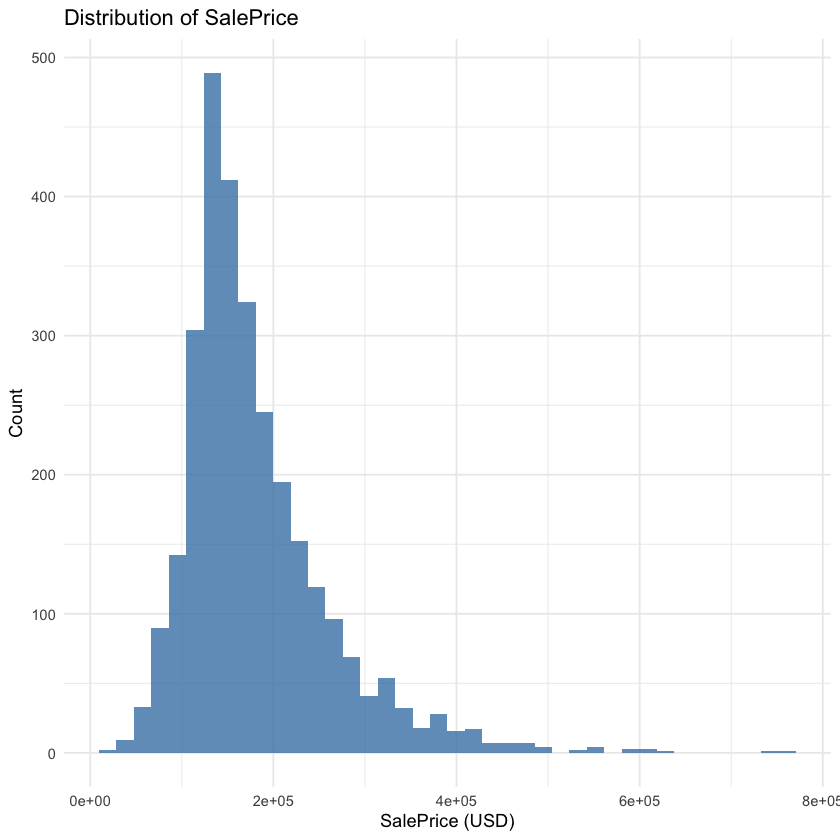

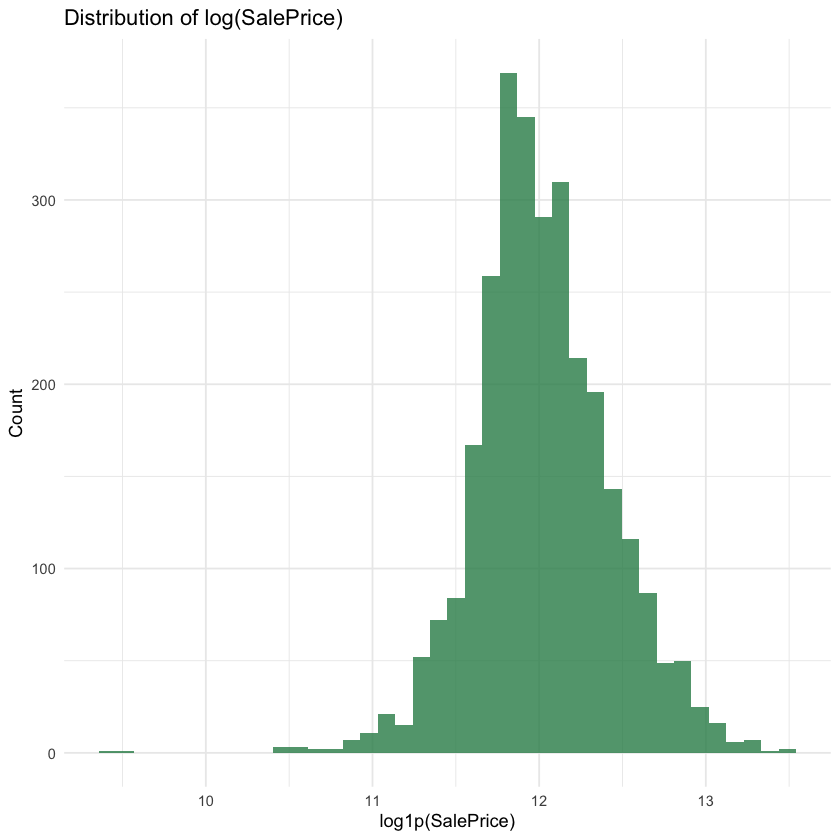

In [19]:
p1 <- ggplot(ames, aes(x = sale_price)) +
        geom_histogram(bins = 40, fill = "steelblue", alpha = 0.8) +
        labs(title = "Distribution of SalePrice", x = "SalePrice (USD)", y = "Count") +
        theme_minimal()

p2 <- ggplot(ames, aes(x = log_sale_price)) +
        geom_histogram(bins = 40, fill = "seagreen", alpha = 0.8) +
        labs(title = "Distribution of log(SalePrice)", x = "log1p(SalePrice)", y = "Count") +
        theme_minimal()

print(p1)
print(p2)

Narysowalimy dwa wykresy, dokaldniej rzecz ujmujac histogramy.  
Histogram dla SalePrice (niebieski) oraz dla log(SalePrice) (zielony).  
  
> **SalePrice** ma dlugi prawy ogon, gdy **log(SalePrice)** jest bardziej skupione wokol sredniej.

In [20]:
skew_raw  <- skewness(ames$sale_price)
skew_log  <- skewness(ames$log_sale_price)

In [21]:
cat("Skewness of SalePrice        :", round(skew_raw,  2), "\n")
cat("Skewness of log(SalePrice)   :", round(skew_log, 2), "\n")

Skewness of SalePrice        : 1.74 


Skewness of log(SalePrice)   : -0.01 


Nastepnie badamy skosnosc obu cech.  
I dochodzimy do konkluzji, ze...  
Generalanie do  przeprwoadzenia regresji wielorakiej lepiej nadaje sie log(SalePrice) chociazby dlatego, ze jej skosnosc jest na poziomie ***-0.01*** co jest znacznie lepsze niz ***1.74***, w przypadku regresji wielorakiej ma znaczenie (o tym troche pozniej).  
  
Proces `log-transformacji` tak jakby sciska te duze wartosci i rozciaga male, to dosyc kolokwialnie powiedzianie, ale wydaje mi sie ze dobrze to oddaje sedno sprawy.
- rozklad w rezultacie zbliza sie do symetrii (skosnosc -> 0)
- zniakaj ogony (odstajace reszty)
  
Warto tez dodac ze do `homoskedatycznosci` tez lepiej nada sie wlasnie zlogotransformowana wartosc SalePrice.  

> Wybieramy ***log(SalePrice)*** do naszej regresji wielorakiej!


### Regresja wieloraka

In [22]:
ames_model <- ames |> 
  select(-sale_price) 

Usuniecie cechy `sale_price`, poniewaz zdecydowalismy sie na `log(sale_price)`.